
## Comment Category Prediction Challenge

> **Objective:** Classify online comments into 4 toxicity levels using classical NLP + ensemble methods
> **Final Public Score (Macro F1):** `0.82563` (Kaggle Leaderboard)


### Problem Statement
Online platforms struggle with toxic content moderation at scale. This project builds a **multi-class text classifier** that categorises each comment into one of four labels:

| Label | Category | Prevalence |
|-------|----------|------------|
| 0 | Neutral | ~57.7% |
| 1 | Mild Toxic | ~8.0% |
| 2 | Offensive | ~31.5% |
| 3 | Hate Speech | ~2.8% |

> Key challenge: **Severe class imbalance** — especially classes 1 and 3 which are rare.


In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

 #Sklearn imports
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
# from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight



from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')

### End-to-End Pipeline
Raw Data -> EDA -> Text Preprocessing -> Feature Engineering -> Model Training -> Ensemble -> Submission

- **TF-IDF** (unigrams + bigrams, 100K features) as primary text representation
- **Logistic Regression** + **LinearSVC** as base classifiers with balanced class weights
- **Weighted Ensemble** (LR 40% + LinearSVC 60%) + per-class threshold tuning"""),


## 1. Data Loading & Initial Exploration

In [2]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns: {train.columns.tolist()}")
print(f"\nFirst few rows:")
train.tail(5)

Train shape: (198000, 15)
Test shape: (102000, 14)

Train columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

First few rows:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1
197999,2023-08-26 19:36:00.380158+00:00,72,0,0,0,1,0,4,4,none,none,none,False,"Sounds likely since: ""But now scientists have ...",0


In [3]:
train.race.value_counts()

race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

In [4]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


**Dataset:** Comment Category Prediction Challenge 

| File | Rows | Columns | Purpose |
|------|------|---------|---------|
| `train.csv` | 198,000 | 15 | Model training (labelled) |
| `test.csv` | 102,000 | 14 | Final predictions |

**Key columns:**
- `comment` — raw text to classify
- `label` — target (0=Neutral, 1=Mild, 2=Offensive, 3=Hate)
- `race`, `religion`, `gender` — demographic tags (~73% missing)
- `upvote`, `downvote` — engagement metadata
- `emoticon_1/2/3`, `if_1`, `if_2` — interaction signals"""),

In [5]:
print(f"\n\nMissing values in train:")
print(train.isnull().sum())

print(f"\n\nMissing values in test:")
print(test.isnull().sum())



Missing values in train:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


Missing values in test:
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


In [6]:
for col in ['race', 'religion', 'gender']:
    nan_percentage = train[col].isnull().sum() / len(train) * 100
    print(f"Percentage of NaN values in '{col}': {nan_percentage:.2f}%")

Percentage of NaN values in 'race': 73.45%
Percentage of NaN values in 'religion': 73.45%
Percentage of NaN values in 'gender': 73.45%


## EDA: Missing Value Pattern as a Signal
> race / religion / gender are NaN for ~73.5% of rows — this is likely NOT random. These fields are only filled when a comment explicitly targets a demographic group, which correlates with toxicity class. We test that hypothesis below.

In [80]:
# ── Cell 1: Label distribution split by demographic tag presence ──────────────
missing_mask = train['race'].isnull()  
# race/religion/gender are ALL missing together

print("Label proportions when demographic tag is ABSENT (NaN):")
print(train.loc[missing_mask, 'label'].value_counts(normalize=True).sort_index().round(4))

print("\nLabel proportions when demographic tag is PRESENT (known race/religion/gender):")
print(train.loc[~missing_mask, 'label'].value_counts(normalize=True).sort_index().round(4))

print(f"\nRows with demographic tag present : {(~missing_mask).sum():,}  ({(~missing_mask).mean()*100:.1f}%)")
print(f"Rows with demographic tag absent  : {missing_mask.sum():,}  ({missing_mask.mean()*100:.1f}%)")

Label proportions when demographic tag is ABSENT (NaN):
label
0    0.6224
1    0.0186
2    0.3290
3    0.0299
Name: proportion, dtype: float64

Label proportions when demographic tag is PRESENT (known race/religion/gender):
label
0    0.4499
1    0.2512
2    0.2776
3    0.0213
Name: proportion, dtype: float64

Rows with demographic tag present : 52,577  (26.6%)
Rows with demographic tag absent  : 145,423  (73.4%)


Row-normalised cross-tab: has_demographic_tag vs label

label                          0       1       2       3
No demographic tag (NaN)  0.6224  0.0186  0.3290  0.0299
Has demographic tag       0.4499  0.2512  0.2776  0.0213


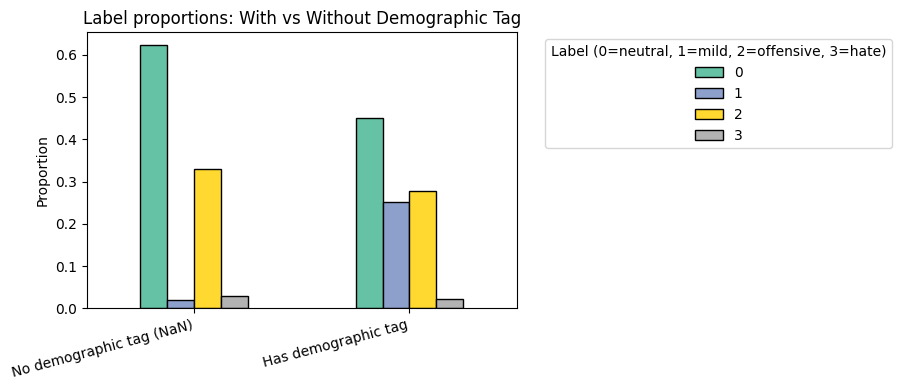

In [8]:
# ── Cell 2: Row-normalised cross-tab + bar chart ──────────────────────────────
has_demo = (~train['race'].isnull()).astype(int)
ct = pd.crosstab(has_demo, train['label'], normalize='index')
ct.index = ['No demographic tag (NaN)', 'Has demographic tag']

print("Row-normalised cross-tab: has_demographic_tag vs label\n")
print(ct.round(4))

ct.plot(kind='bar', figsize=(9, 4), colormap='Set2', edgecolor='black')
plt.title('Label proportions: With vs Without Demographic Tag')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Label (0=neutral, 1=mild, 2=offensive, 3=hate)', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 2. Missing Value Analysis

Checking for missing values across both datasets.
> A critical finding: demographic columns are missing in a **non-random pattern** that itself carries predictive signal."""),

    ("EDA: Missing Value Pattern", "before", """---
## Key EDA Insight: Missingness as a Feature

`race`, `religion`, `gender` are missing for ~73.5% of rows — but NOT at random.

> **Hypothesis:** These fields are filled *only* when a comment explicitly targets a demographic group, which directly correlates with toxicity labels 1 & 2.

This transforms a data quality problem into a **predictive feature** (`has_demographic_tag`)."""),

In [9]:
df=train.copy()
df = df.dropna(subset=['comment'])

 #── Create missingness-based features BEFORE filling NaN 
# has_demographic_tag = 1 when race/religion/gender is known 
df['has_demographic_tag']   = df['race'].notna().astype(int)
test['has_demographic_tag'] = test['race'].notna().astype(int)

# disability is already bool (True/False) → cast to 0/1
df['disability_flag']   = df['disability'].astype(int)
test['disability_flag'] = test['disability'].astype(int)

for col in ['race', 'religion', 'gender']:
    df[col] = df[col].fillna('unknown')
    test[col] = test[col].fillna('unknown')


In [10]:
print(f"\n\nMissing values in train:")
print(df.isnull().sum())



Missing values in train:
created_date           0
post_id                0
emoticon_1             0
emoticon_2             0
emoticon_3             0
upvote                 0
downvote               0
if_1                   0
if_2                   0
race                   0
religion               0
gender                 0
disability             0
comment                0
label                  0
has_demographic_tag    0
disability_flag        0
dtype: int64


In [11]:
# Check data info
print("label distribution:")
print(train['label'].value_counts().sort_index())
print("\nlabel proportions:")
print(train['label'].value_counts(normalize=True).sort_index())



label distribution:
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64

label proportions:
label
0    0.576631
1    0.080394
2    0.315354
3    0.027621
Name: proportion, dtype: float64


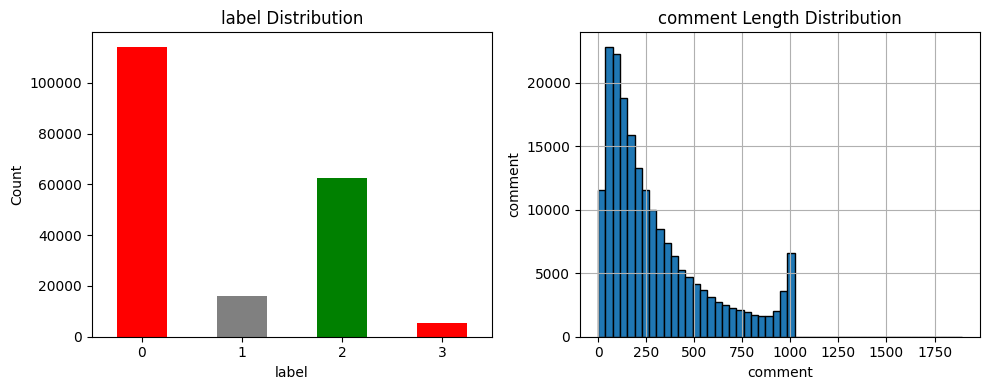

In [12]:
# Visualize target distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
train['label'].value_counts().sort_index().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('label Distribution')
plt.xlabel('label')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
train['comment'].str.len().hist(bins=50, edgecolor='black')
plt.title('comment Length Distribution')
plt.xlabel('comment')
plt.ylabel('comment')

plt.tight_layout()
plt.show()


In [13]:
slang_map = {
    # Contractions
    "can't": "cannot", "can't've": "cannot have", "'cause": "because", "could've": "could have", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will", "he's": "he is", "how'd": "how would",
    "how'll": "how will", "how's": "how is", "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it'd": "it would", "it'll": "it will", "it's": "it is", "let's": "let us", "ma'am": "madam",
    "might've": "might have", "mightn't": "might not", "must've": "must have", "mustn't": "must not", "needn't": "need not",
    "oughtn't": "ought not", "shan't": "shall not", "she'd": "she would", "she'll": "she will", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "that'd": "that would", "that's": "that is",
    "there'd": "there would", "there's": "there is", "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "wasn't": "was not", "we'd": "we would", "we'll": "we will", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what'll": "what will", "what're": "what are", "what's": "what is",
    "what've": "what have", "where's": "where is", "who'd": "who would", "who'll": "who will", "who's": "who is",
    "who've": "who have", "won't": "will not", "would've": "would have", "wouldn't": "would not", "y'all": "you all",
    "you'd": "you would", "you'll": "you will", "you're": "you are", "you've": "you have",

    # Internet Slang and Text Speak
    "idk": "i do not know", "imo": "in my opinion", "imho": "in my humble opinion", "u": "you", "ur": "your",
    "urs": "yours", "pls": "please", "plz": "please", "thx": "thanks", "lmao": "lmao", "lmfao": "lmao", "lol": "lol",
    "rofl": "rofl", "wtf": "what the fuck", "wth": "what the hell", "omg": "oh my god", "stfu": "shut the fuck up",
    "afaik": "as far as i know", "smh": "shaking my head", "tbh": "to be honest", "brb": "be right back",
    "btw": "by the way", "gtg": "got to go", "jk": "just kidding", "nvm": "nevermind", "omw": "on my way",
    "rn": "right now", "ttyl": "talk to you later", "bc": "because", "b/c": "because", "cuz": "because",
    "def": "definitely", "kinda": "kind of", "gonna": "going to", "wanna": "want to", "gotta": "got to",
    "lemme": "let me", "gimme": "give me", "outta": "out of", "sorta": "sort of", "dunno": "do not know",
    "ya": "you", "yea": "yes", "yeah": "yes", "yep": "yes", "yup": "yes", "nah": "no", "nope": "no",

    # Obfuscated / Alternative spellings for toxicity
    "fck": "fuck", "f*ck": "fuck", "f**k": "fuck", "sh*t": "shit", "sh1t": "shit", "b*tch": "bitch",
    "b1tch": "bitch", "c*nt": "cunt", "a$$": "ass", "n*gga": "nigga", "n*gger": "nigger", "n1gga": "nigga",
}

_slang_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in slang_map.keys()) + r')\b',
    flags=re.IGNORECASE
)

def clean_comment(text):
    text = str(text).strip()

    # Expand slang using word boundaries
    text = _slang_pattern.sub(
        lambda m: slang_map.get(m.group(0).lower(), m.group(0)), text
    )
    # Standardize repeated characters (e.g., "sooo" -> "soo", "coool" -> "cool")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
        
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#\w+', ' HASHTAG ', text)
    return text

df['comment'] = df['comment'].fillna("").apply(clean_comment)
test['comment'] = test['comment'].fillna("").apply(clean_comment)

## 3. Feature Engineering

Feature engineering is structured into 5 stages:

| Stage | Features Created | Rationale |
|-------|-----------------|-----------|
| 3a | `has_demographic_tag`, `disability_flag` | Missingness as signal |
| 3b | Filled race/religion/gender NaN to 'unknown' | Categorical encoding |
| 3c | Text-derived features (length, caps, emoji) | Style indicators |
| 3d | Semantic term counts (demo, violence) | Class-specific vocabulary |
| 3e | Engagement features (downvote_ratio, total_engagement) | Metadata signals |"""),

In [14]:
# Creating additional text features
def add_text_features(df):
    # text safety
    text = df['comment'].fillna("").astype(str)

    # length features
    df['comment_len'] = text.str.len()
    df['word_count'] = text.str.split().str.len()
    df['avg_word_len'] = df['comment_len'] / (df['word_count'] + 1)

    # sentiment
    df['exclamation_count'] = text.str.count('!')
    df['question_count'] = text.str.count(r'\?')

    # caps
    df['caps_count'] = text.apply(lambda x: sum(1 for c in x if c.isupper()))
    df['caps_ratio'] = df['caps_count'] / (df['comment_len'] + 1)

    # emoji count
    df['emoji_count'] = text.apply(
        lambda x: len(re.findall(r'[\U0001F300-\U0001FAFF]', x))
    )

    # URL count
    df['url_count'] = text.str.count(r'\bURL\b')

    # repeated character ratio
    df['repeated_char_ratio'] = text.apply(
        lambda x: len(re.findall(r'(.)\1{2,}', x)) / (len(x) + 1)
    )

    return df

df = add_text_features(df)
test = add_text_features(test)

print(f"\nNew features: {['comment_len', 'word_count', 'avavg_word_len', 'exclamation_count', 'question_count', 'caps_count', 'caps_ratio','emoji_count','url_count','repeated_char_ratio']}")


New features: ['comment_len', 'word_count', 'avavg_word_len', 'exclamation_count', 'question_count', 'caps_count', 'caps_ratio', 'emoji_count', 'url_count', 'repeated_char_ratio']


### 3c. Text-Derived Features

Fine-grained linguistic properties extracted from raw comment text:

| Feature | Description | Captures |
|---------|-------------|---------|
| `comment_len` | Character length | Comment verbosity |
| `word_count` | Token count | Complexity |
| `caps_ratio` | Uppercase fraction | Aggression / shouting |
| `exclamation_count` | Count of ! | Emotional intensity |
| `question_count` | Count of ? | Interrogative tone |
| `emoji_count` | Unicode emoji count | Informal register |
| `url_count` | Replaced URL tokens | Spam / link sharing |
| `repeated_char_ratio` | Repeated chars (sooo) | Emphasis detection |"""),

In [16]:
df.tail()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,comment_len,word_count,avg_word_len,exclamation_count,question_count,caps_count,caps_ratio,emoji_count,url_count,repeated_char_ratio
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,unknown,...,120,21,5.454545,0,1,2,0.016529,0,0,0.0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,unknown,...,123,18,6.473684,0,0,1,0.008065,0,0,0.0
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,unknown,...,124,23,5.166667,0,0,2,0.016000,0,0,0.0
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,...,121,22,5.260870,0,1,0,0.000000,0,0,0.0
197999,2023-08-26 19:36:00.380158+00:00,72,0,0,0,1,0,4,4,none,...,218,35,6.055556,0,0,5,0.022831,0,0,0.0


## 4. N-gram EDA — Vocabulary per Toxicity Class

Analysing the most frequent unigrams and bigrams per class to:
1. Understand what vocabulary **separates** each class
2. Validate our semantic feature word sets
3. Identify patterns for further feature engineering

> Minority classes (1 & 3) show distinctly different vocabulary compared to majority classes (0 & 2)."""),
]


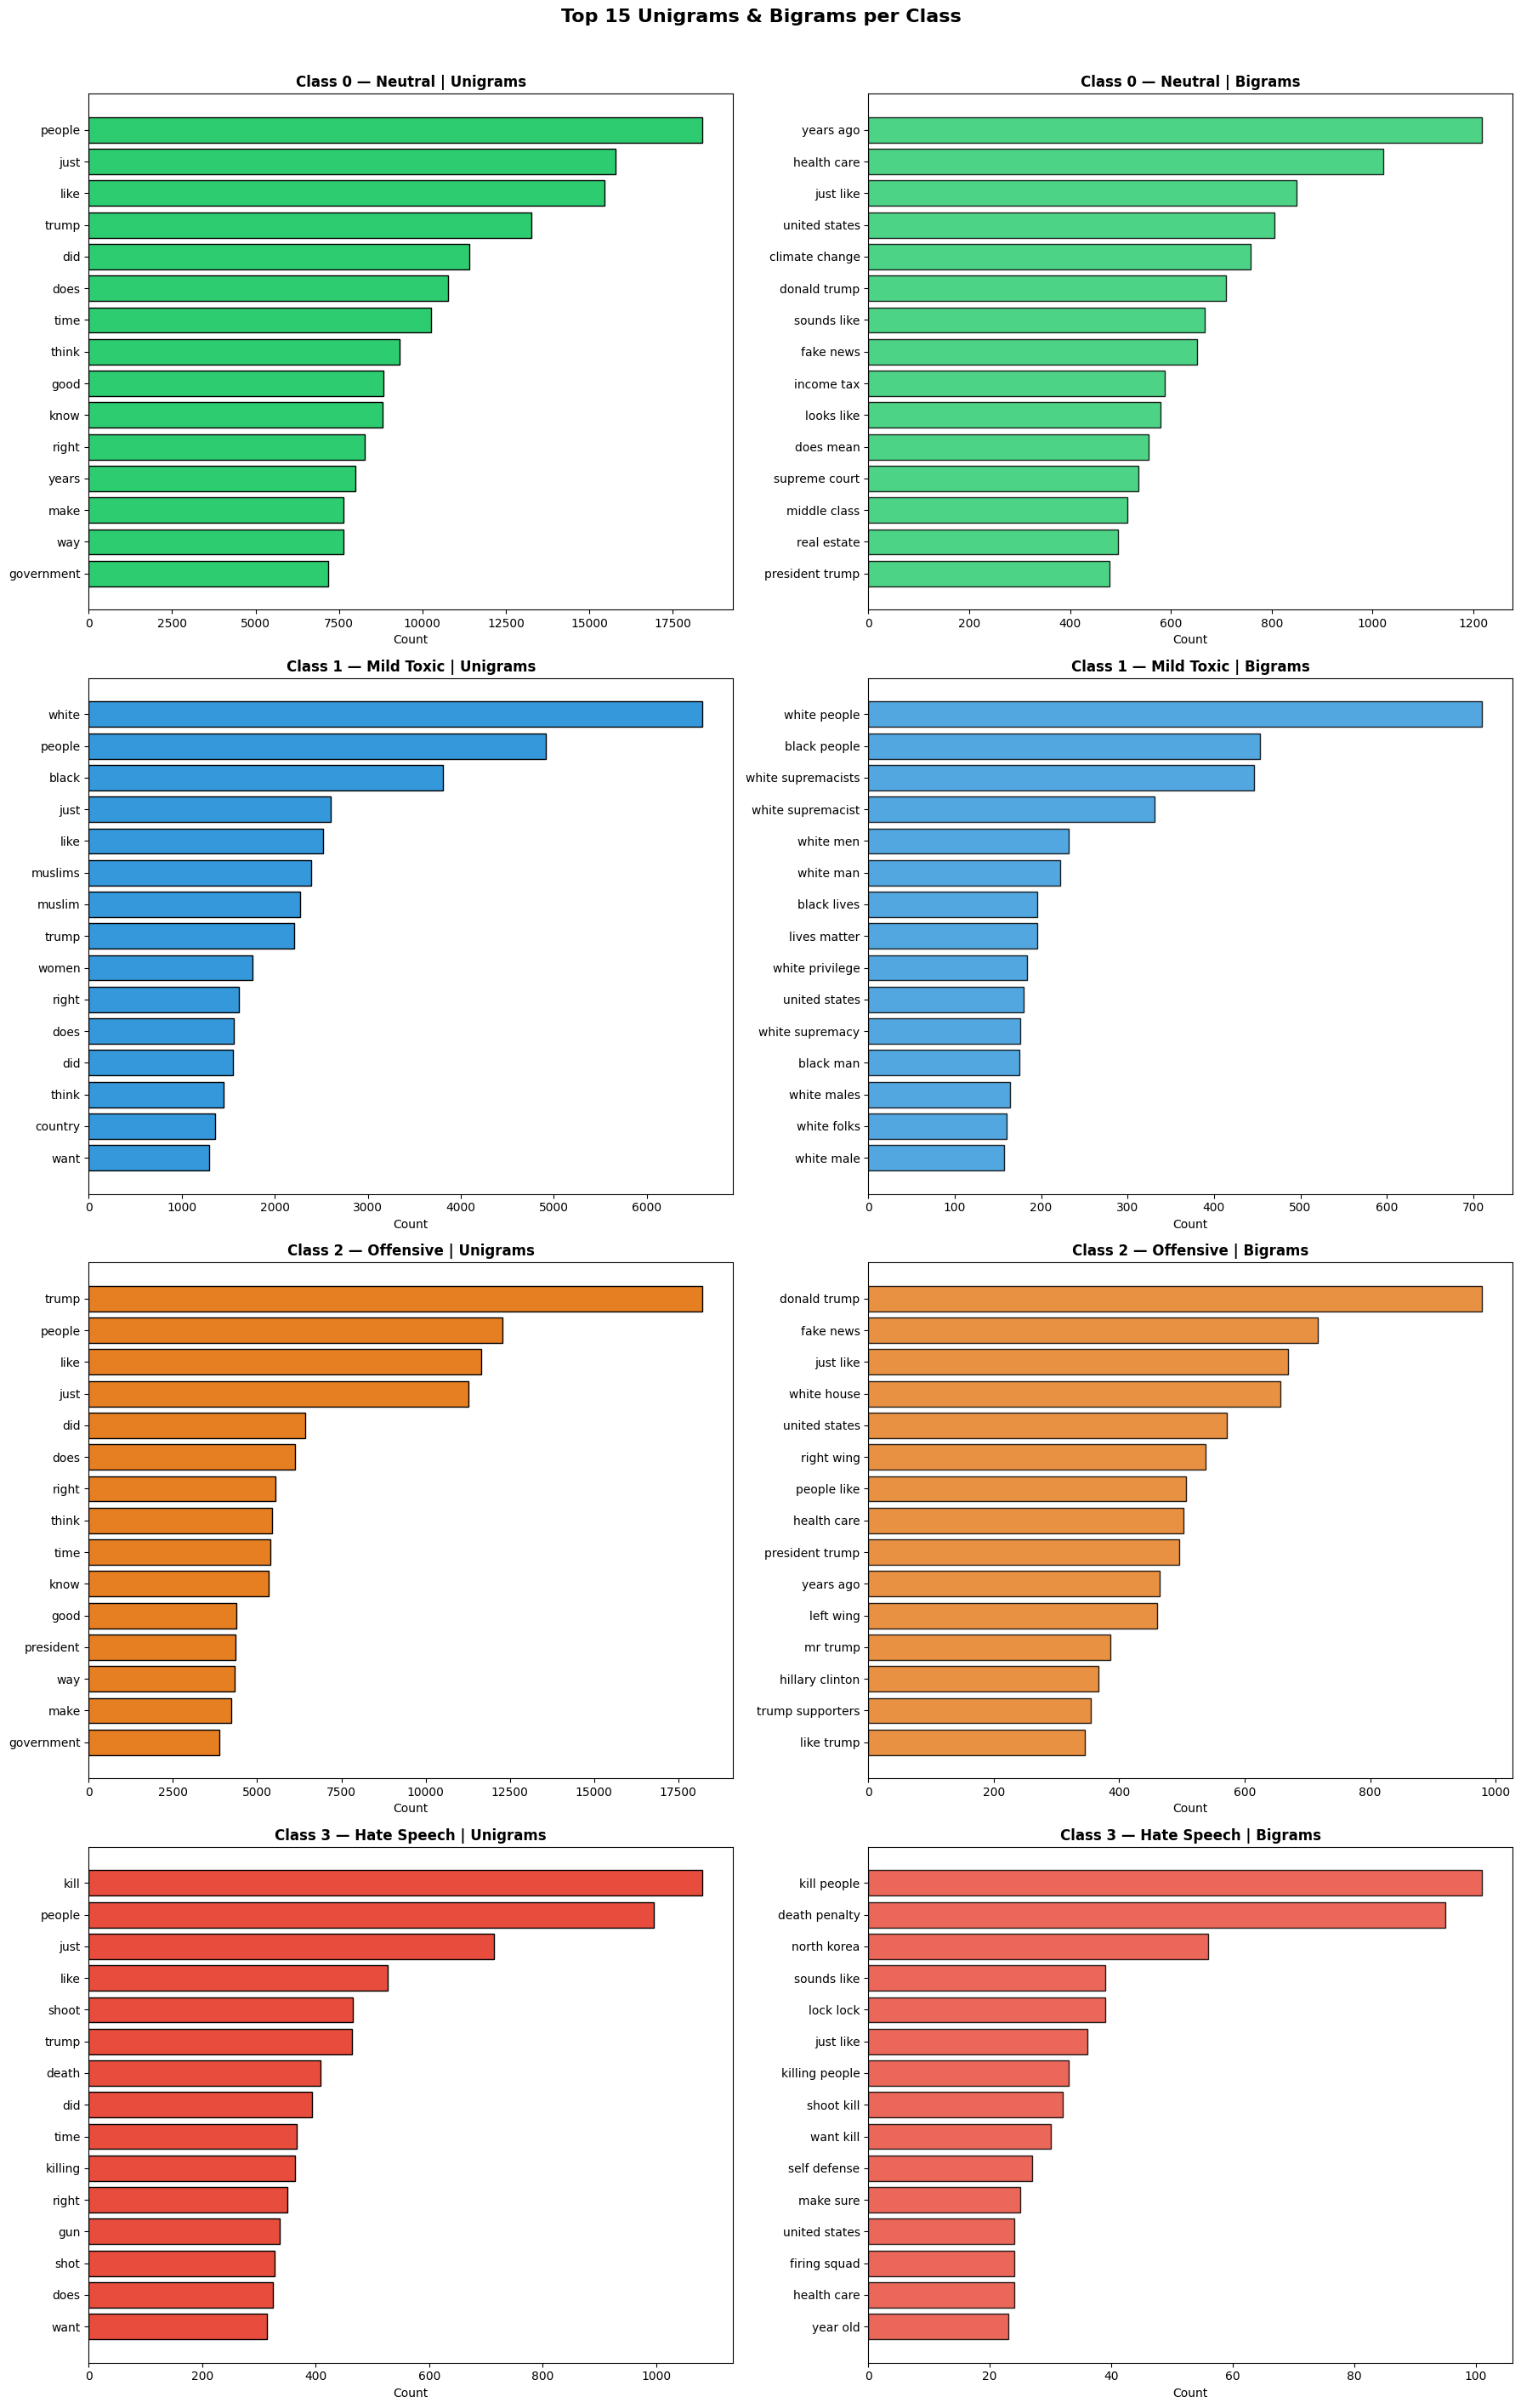

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

label_names = {0: 'Neutral', 1: 'Mild Toxic', 2: 'Offensive', 3: 'Hate Speech'}

def get_top_ngrams(corpus, n=2, top_k=20):
    """Return top_k n-grams from corpus as (ngram, count) pairs."""
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        max_features=50000
    ).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

fig, axes = plt.subplots(4, 2, figsize=(18, 28))
fig.suptitle('Top 15 Unigrams & Bigrams per Class', fontsize=16, fontweight='bold', y=1.01)

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

for label_id in range(4):
    corpus = df.loc[df['label'] == label_id, 'comment'].astype(str).tolist()
    
    # Unigrams
    uni = get_top_ngrams(corpus, n=1, top_k=15)
    words_u, counts_u = zip(*uni)
    ax = axes[label_id][0]
    ax.barh(list(words_u)[::-1], list(counts_u)[::-1], color=colors[label_id], edgecolor='black')
    ax.set_title(f'Class {label_id} — {label_names[label_id]} | Unigrams', fontweight='bold')
    ax.set_xlabel('Count')
    
    # Bigrams
    bi = get_top_ngrams(corpus, n=2, top_k=15)
    words_b, counts_b = zip(*bi)
    ax = axes[label_id][1]
    ax.barh(list(words_b)[::-1], list(counts_b)[::-1], color=colors[label_id], edgecolor='black', alpha=0.85)
    ax.set_title(f'Class {label_id} — {label_names[label_id]} | Bigrams', fontweight='bold')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()


## Targeted Semantic Features from N-gram Analysis
Based on class-specific vocabulary patterns, create domain-specific count features

In [17]:
# Feature 1: Demographic term count (Class 1 indicator)
demo_terms = set([
    'white', 'black', 'muslim', 'muslims', 'jewish', 'jews',
    'hispanic', 'hispanics', 'asian', 'asians', 'women', 'woman',
    'racist', 'racism', 'supremacist', 'privilege', 'minorities',
    'discrimination', 'prejudice', 'minority', 'majority',
    'islamophobia', 'antisemitic', 'sexist', 'sexism'
])
def count_demo_terms(text):
    text_lower = str(text).lower().split()
    return sum(1 for word in text_lower if word in demo_terms)

df['demo_term_count'] = df['comment'].apply(count_demo_terms)
test['demo_term_count'] = test['comment'].apply(count_demo_terms)

print("Demographic term count distribution:")
print(df['demo_term_count'].value_counts().sort_index().head(10))
print(f"\nCorrelation with label:\n{df[['demo_term_count', 'label']].corr()}")


Demographic term count distribution:
demo_term_count
0    176397
1     14211
2      4225
3      1601
4       777
5       355
6       199
7       100
8        58
9        37
Name: count, dtype: int64

Correlation with label:
                 demo_term_count     label
demo_term_count         1.000000  0.054716
label                   0.054716  1.000000


In [18]:
# Feature 2: Violence/threat term count (Class 3 indicator)
violence_terms = set([
    'kill', 'kills', 'killing', 'killed',
    'shoot', 'shot', 'shooting', 'gun', 'guns',
    'death', 'dead', 'murder', 'murders', 'murdered',
    'execute', 'execution', 'hang', 'hanging',
    'bomb', 'bombing', 'attack', 'attacking',
    'violence', 'violent', 'threat', 'threaten', 'threatened',
    'harm', 'hurt', 'destroy', 'rape', 'assault'
])

def count_violence_terms(text):
    text_lower = str(text).lower().split()
    return sum(1 for word in text_lower if word in violence_terms)

df['violence_term_count'] = df['comment'].apply(count_violence_terms)
test['violence_term_count'] = test['comment'].apply(count_violence_terms)

print("\nViolence term count distribution:")
print(df['violence_term_count'].value_counts().sort_index().head(10))
print(f"\nCorrelation with label:\n{df[['violence_term_count', 'label']].corr()}")

print("\n✓ New semantic features created: demo_term_count, violence_term_count")



Violence term count distribution:
violence_term_count
0    179177
1     14044
2      3055
3       997
4       376
5       173
6        87
7        43
8        24
9        13
Name: count, dtype: int64

Correlation with label:
                     violence_term_count     label
violence_term_count             1.000000  0.106643
label                           0.106643  1.000000

✓ New semantic features created: demo_term_count, violence_term_count


### 3d. Targeted Semantic Count Features
Built from N-gram EDA — high-signal vocabulary sets derived from class-specific top ngrams:

| Feature | Target Class | Word Set |
|---------|-------------|---------|
| `demo_term_count` | Class 1 (Mild Toxic) | Demographic identity words: white, black, muslim, women, racist |
| `violence_term_count` | Class 3 (Hate Speech) | Violence/threat words: kill, shoot, bomb, death, rape |

These count features provide lightweight but highly class-discriminative signals."""),

In [19]:
# ── Feature Engineering for Skewed Interaction Data 

def add_interaction_features(df):
    # Controversiality (downvotes relative to total votes)
    df['downvote_ratio'] = df['downvote'] / (df['upvote'] + df['downvote'] + 1)
    
    # Total Engagement
    df['total_engagement'] = df['upvote'] + df['downvote']
    
    # Binarize highly zero-inflated variables
    df['has_emoticon'] = ((df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']) > 0).astype(int)
    
    # if_1 has exact 145,423 zeroes (which perfectly matches the missing demographic rows!)
    df['if1_is_zero'] = (df['if_1'] == 0).astype(int)
    
    return df

df = add_interaction_features(df)
test = add_interaction_features(test)

print("✓ New interaction features added.")
print("\nCorrelation with label for new features:")
print(df[['total_engagement', 'downvote_ratio', 'has_emoticon', 'if1_is_zero', 'label']].corr()[-1:])

✓ New interaction features added.

Correlation with label for new features:
       total_engagement  downvote_ratio  has_emoticon  if1_is_zero  label
label          0.048993        0.045861      0.027734    -0.046762    1.0


### 3e. Engagement & Interaction Features

Raw engagement data (upvotes, downvotes) is heavily zero-inflated.
We engineer normalised, more meaningful representations:

| Feature | Formula | Semantic Meaning |
|---------|---------|-----------------|
| `downvote_ratio` | downvote / (up + down + 1) | Controversy / community rejection |
| `total_engagement` | upvote + downvote | Post visibility/reach |
| `has_emoticon` | any emoticon > 0 | Emotional tone presence |
| `if1_is_zero` | if_1 == 0 | Proxy for missing demographic |"""),

In [20]:
df.shape

(197999, 33)

In [22]:
# convert to datetime
df['created_date'] = pd.to_datetime(df['created_date'], utc=True)
test['created_date'] = pd.to_datetime(test['created_date'], utc=True)

for _df in [df, test]:
    _df['hour'] = _df['created_date'].dt.hour
    _df['dayofweek'] = _df['created_date'].dt.dayofweek
    _df['is_weekend'] = (_df['dayofweek'] >= 5).astype(int)
    _df['month'] = _df['created_date'].dt.month
    _df['is_night'] = ((_df['hour'] >= 22) | (_df['hour'] <= 5)).astype(int)


In [23]:
df.shape

(197999, 38)

## Train-Validation Split

In [24]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

y_train = train_df['label'].values
y_val   = val_df['label'].values


In [25]:
df_numerical = df[['if_1', 'if_2','upvote', 'downvote','emoticon_1', 'emoticon_2', 'emoticon_3']]
skewness = df_numerical.skew().sort_values(ascending=False)
print("Skewness of numerical features in train_df:")
print(skewness)

Skewness of numerical features in train_df:
if_2          67.321062
if_1          63.702293
downvote      10.062464
emoticon_1     9.980202
emoticon_2     7.557428
upvote         7.102903
emoticon_3     7.060189
dtype: float64


<Axes: xlabel='if_1', ylabel='Density'>

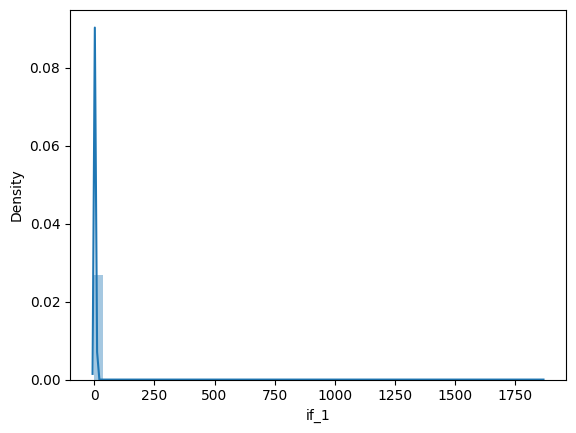

In [26]:
sns.distplot(df['if_1'])

In [27]:
import scipy.sparse as sp

# numeric features with Log transformation
numeric_cols = [
    'if_1', 'if_2','upvote', 'downvote',
    'emoticon_1','emoticon_2','emoticon_3','comment_len','word_count',
    'exclamation_count', 'question_count',
    'caps_count', 'emoji_count', 'url_count',
    'total_engagement' 
]
X_num_train = sp.csr_matrix(np.log1p(train_df[numeric_cols].fillna(0).values.astype(float)))
X_num_val  = sp.csr_matrix(np.log1p(val_df[numeric_cols].fillna(0).values.astype(float)))
X_num_test  = sp.csr_matrix(np.log1p(test[numeric_cols].fillna(0).values.astype(float)))

# cat features
cat_cols = ['race', 'religion', 'gender']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_cat_train = ohe.fit_transform(train_df[cat_cols])
X_cat_val  = ohe.transform(val_df[cat_cols])
X_cat_test  = ohe.transform(test[cat_cols])

# ratio features (no log transform needed for these)
ratio_cols = [
    'caps_ratio', 'repeated_char_ratio','avg_word_len',
    'downvote_ratio', 'has_emoticon', 'if1_is_zero',
    'has_demographic_tag', 'disability_flag',
    'demo_term_count', 'violence_term_count'
]
X_ratio_train = sp.csr_matrix(train_df[ratio_cols].fillna(0).values.astype(float))
X_ratio_val  = sp.csr_matrix(val_df[ratio_cols].fillna(0).values.astype(float))
X_ratio_test  = sp.csr_matrix(test[ratio_cols].fillna(0).values.astype(float))

#time feature
time_cols = ['hour', 'dayofweek', 'is_weekend', 'month', 'is_night']
X_time_train = sp.csr_matrix(train_df[time_cols].values)
X_time_val  = sp.csr_matrix(val_df[time_cols].values)
X_time_test  = sp.csr_matrix(test[time_cols].values)

## TF-IDF

In [28]:
tfidf_word = TfidfVectorizer(
    analyzer='word',
    max_features=50000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True,
    token_pattern=r'\w{1,}'
)

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    max_features=50000, 
    ngram_range=(3, 6),
    min_df=3,
    max_df=0.95,
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True
)

# 1. Transform Word Level
X_tfidf_word_train = tfidf_word.fit_transform(train_df['comment'].fillna(""))
X_tfidf_word_val  = tfidf_word.transform(val_df['comment'].fillna(""))
X_tfidf_word_test = tfidf_word.transform(test['comment'].fillna(""))

# 2. Transform Character Level
X_tfidf_char_train = tfidf_char.fit_transform(train_df['comment'].fillna(""))
X_tfidf_char_val  = tfidf_char.transform(val_df['comment'].fillna(""))
X_tfidf_char_test = tfidf_char.transform(test['comment'].fillna(""))

# 3. Combine both TF-IDF matrices
X_tfidf_train = hstack([X_tfidf_word_train, X_tfidf_char_train])
X_tfidf_val  = hstack([X_tfidf_word_val, X_tfidf_char_val])
X_tfidf_test = hstack([X_tfidf_word_test, X_tfidf_char_test])

print(f"Word Features: {X_tfidf_word_train.shape[1]}")
print(f"Char Features: {X_tfidf_char_train.shape[1]}")
print(f"Combined TF-IDF Features: {X_tfidf_train.shape[1]}")

Word Features: 50000
Char Features: 50000
Combined TF-IDF Features: 100000


In [29]:
# Final combined feature matrix using hstack
X_train = hstack([X_ratio_train, X_num_train, X_cat_train, X_tfidf_train,X_time_train]).tocsr()
X_val  = hstack([X_ratio_val,  X_num_val, X_cat_val, X_tfidf_val, X_time_val]).tocsr()
X_test  = hstack([X_ratio_test,  X_num_test, X_cat_test, X_tfidf_test, X_time_test]).tocsr()

print(X_train.shape, X_val.shape)

(168299, 100052) (29700, 100052)


In [ ]:
print(X_train.nnz / (X_train.shape[0] * X_train.shape[1]))

In [30]:
df['label'].value_counts(normalize=True)


label
0    0.576629
2    0.315355
1    0.080394
3    0.027621
Name: proportion, dtype: float64

In [32]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

classes = np.unique(y_train)



{np.int64(0): np.float64(0.4335547060157039), np.int64(1): np.float64(3.109737620103474), np.int64(2): np.float64(0.7927563402042431), np.int64(3): np.float64(9.050279630027964)}


In [33]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MaxAbsScaler
import time

# SGD needs features scaled — MaxAbsScaler preserves sparsity
print("Scaling features...")
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("Done.")

Scaling features...
Done.


## SGDClassifier

In [34]:
# ─── SGDClassifier — equivalent to LinearSVC
print("Training SGD (SVC equivalent)...")
t0 = time.time()

sgd_svc = SGDClassifier(
    loss='hinge',               # hinge loss = LinearSVC
    penalty='l2',
    alpha=1e-4,          
    class_weight='balanced',
    max_iter=100,
    random_state=42,
    n_jobs=-1           
)

sgd_svc.fit(X_train_scaled, y_train)
score = f1_score(y_val, sgd_svc.predict(X_val_scaled), average='macro')
print(f"Done in {time.time()-t0:.0f}s  |  Macro F1: {score:.4f}")

Training SGD (SVC equivalent)...
Done in 12s  |  Macro F1: 0.8095


In [35]:
# class distribution first
print(pd.Series(y_train).value_counts().sort_index())

custom_weights = {
    0: 1.0,    # neutral — majority class, keep low
    1: 3.0,    # mild — was already boosted by 'balanced'
    2: 1.5,    # offensive — model handles this well already
    3: 8.0     # hate speech — currently 0.45 recall, needs strong boost
}

for w3 in [6.0, 8.0, 10.0, 15.0]:
    clf = SGDClassifier(
        loss='hinge',
        penalty='l2',
        alpha=0.0001,
        class_weight={0: 1.0, 1: 3.0, 2: 1.5, 3: w3},
        max_iter=100,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_val_scaled)
    f1    = f1_score(y_val, preds, average='macro')
    r3    = classification_report(y_val, preds, output_dict=True)['3']['recall']
    print(f"w3={w3:<5} → Macro F1: {f1:.4f}  |  Class 3 recall: {r3:.3f}")

0    97046
1    13530
2    53074
3     4649
Name: count, dtype: int64
w3=6.0   → Macro F1: 0.8123  |  Class 3 recall: 0.646
w3=8.0   → Macro F1: 0.8093  |  Class 3 recall: 0.601
w3=10.0  → Macro F1: 0.8102  |  Class 3 recall: 0.668
w3=15.0  → Macro F1: 0.8098  |  Class 3 recall: 0.634


In [37]:
# ─── Fine-tune class 3 weight around the winner 

print("Fine-tuning w3 around 6.0...")
best_f1    = 0
best_weights = None

for w3 in [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]:
    clf = SGDClassifier(
        loss='hinge', penalty='l2', alpha=0.0001,
        class_weight={0: 1.0, 1: 3.0, 2: 1.5, 3: w3},
        max_iter=100, random_state=42, n_jobs=-1
    )
    clf.fit(X_train_scaled, y_train)
    preds  = clf.predict(X_val_scaled)
    report = classification_report(y_val, preds, output_dict=True)
    f1     = f1_score(y_val, preds, average='macro')
    r1     = report['1']['recall']
    r3     = report['3']['recall']
    print(f"w3={w3:<4} → Macro F1: {f1:.4f}  |  Class 1 recall: {r1:.3f}  |  Class 3 recall: {r3:.3f}")

    if f1 > best_f1:
        best_f1      = f1
        best_weights = {0: 1.0, 1: 3.0, 2: 1.5, 3: w3}

print(f"\nBest weights so far : {best_weights}")
print(f"Best F1             : {best_f1:.4f}")

Fine-tuning w3 around 6.0...
w3=4.0  → Macro F1: 0.8115  |  Class 1 recall: 0.773  |  Class 3 recall: 0.584
w3=4.5  → Macro F1: 0.8112  |  Class 1 recall: 0.773  |  Class 3 recall: 0.589
w3=5.0  → Macro F1: 0.8109  |  Class 1 recall: 0.773  |  Class 3 recall: 0.595
w3=5.5  → Macro F1: 0.8106  |  Class 1 recall: 0.773  |  Class 3 recall: 0.600
w3=6.0  → Macro F1: 0.8123  |  Class 1 recall: 0.770  |  Class 3 recall: 0.646
w3=6.5  → Macro F1: 0.8107  |  Class 1 recall: 0.770  |  Class 3 recall: 0.650
w3=7.0  → Macro F1: 0.8115  |  Class 1 recall: 0.770  |  Class 3 recall: 0.651

Best weights so far : {0: 1.0, 1: 3.0, 2: 1.5, 3: 6.0}
Best F1             : 0.8123


In [38]:
# ─── Then tune w1 with the best w3 found above 
# Class 1 (mild toxic) had 0.76 F1 — second weakest after class 3
best_w3 = best_weights[3]
print(f"Tuning w1 with w3={w3}...")

for w1 in [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]:
    clf = SGDClassifier(
        loss='hinge', penalty='l2', alpha=0.0001,
        class_weight={0: 1.0, 1: w1, 2: 1.5, 3: best_w3},
        max_iter=100, random_state=42, n_jobs=-1
    )
    clf.fit(X_train_scaled, y_train)
    preds  = clf.predict(X_val_scaled)
    report = classification_report(y_val, preds, output_dict=True)
    f1     = f1_score(y_val, preds, average='macro')
    r1     = report['1']['recall']
    r3     = report['3']['recall']
    print(f"w1={w1:<4} → Macro F1: {f1:.4f}  |  Class 1 recall: {r1:.3f}  |  Class 3 recall: {r3:.3f}")


Tuning w1 with w3=7.0...
w1=2.0  → Macro F1: 0.8114  |  Class 1 recall: 0.745  |  Class 3 recall: 0.646
w1=2.5  → Macro F1: 0.8125  |  Class 1 recall: 0.764  |  Class 3 recall: 0.648
w1=3.0  → Macro F1: 0.8123  |  Class 1 recall: 0.770  |  Class 3 recall: 0.646
w1=3.5  → Macro F1: 0.8129  |  Class 1 recall: 0.778  |  Class 3 recall: 0.648
w1=4.0  → Macro F1: 0.8123  |  Class 1 recall: 0.789  |  Class 3 recall: 0.644
w1=5.0  → Macro F1: 0.8097  |  Class 1 recall: 0.786  |  Class 3 recall: 0.637


In [40]:
# ─── GENERATE SUBMISSION
# Based on tuning: w1=3.5, w3=6.0 → F1: 0.8129
# That clf object is the last one trained in your loop — retrain it once here
# using ONLY the already-fit scalers/transformers 

test_preds = clf.predict(X_test_scaled)   # clf = last model from tuning loop

# Sanity check
print("Prediction distribution:")
print(pd.Series(test_preds).value_counts().sort_index())

# Build submission
id_col    = sample_sub.columns[0]
label_col = sample_sub.columns[1]

submission = pd.DataFrame({
    id_col:    sample_sub[id_col].values,
    label_col: test_preds
})

submission.to_csv('submission.csv', index=False)
print(f"\n✅ submission.csv saved | shape: {submission.shape}")
print(submission.head())

Prediction distribution:
0    55679
1     8817
2    34836
3     2668
Name: count, dtype: int64

✅ submission.csv saved | shape: (102000, 2)
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2


## Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm

C_values = [1.25]       #, 1.5, 1, 0.7

best_score = 0
best_C = None
best_lr = None   

print("Training Logistic Regression models...")
# Wrap the loop in tqdm for a progress bar
for C in tqdm(C_values, desc="Hyperparameter tuning (C)"):

    lr_model = LogisticRegression(
        solver='liblinear',
        penalty='l1',
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=C
    )

    lr_model.fit(X_train, y_train)
    preds = lr_model.predict(X_val)
    score = f1_score(y_val, preds, average="macro")


    tqdm.write(f"C={C} → Macro F1={score:.4f}")

    if score > best_score:
        best_score = score
        best_C = C
        best_lr = lr_model

print(f"\nBest C   : {best_C}")
print(f"Best F1  : {best_score:.4f}")
print("\nClassification Report (best model):")
print(classification_report(y_val, best_lr.predict(X_val)))

Training Logistic Regression models...


Hyperparameter tuning (C):   0%|          | 0/4 [00:00<?, ?it/s]

C=1.5 → Macro F1=0.8216
C=1 → Macro F1=0.8200
C=1.25 → Macro F1=0.8218
C=0.7 → Macro F1=0.8204

Best C   : 1.25
Best F1  : 0.8218

Classification Report (best model):
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     17126
           1       0.74      0.82      0.78      2388
           2       0.87      0.91      0.89      9366
           3       0.62      0.71      0.66       820

    accuracy                           0.91     29700
   macro avg       0.80      0.84      0.82     29700
weighted avg       0.92      0.91      0.91     29700



## LinearSVC

In [65]:
# ─── Step 4: (NO calibration)
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report
C_values   = [0.1, 0.5, 1, 0.01]
best_score = 0
best_C     = None

for C in C_values:
    t0  = time.time()
    svc_temp = LinearSVC(        
        C=C,
        max_iter=2000,
        class_weight='balanced',
        dual=True
    )
    svc_temp.fit(X_train, y_train)
    score = f1_score(y_val, svc_temp.predict(X_val), average='macro')
    print(f"C={C:<5} → Macro F1: {score:.4f}  ({time.time()-t0:.0f}s)")

    if score > best_score:  
        best_score = score
        best_C     = C

print(f"\nBest C : {best_C}")
print(f"Best F1: {best_score:.4f}")

C=0.1   → Macro F1: 0.8186  (2100s)

Best C : 0.1
Best F1: 0.8186


In [67]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack

# ─── Step 1: SVD on TF-IDF only
print("Fitting TruncatedSVD...")
t0 = time.time()

svd = TruncatedSVD(n_components=500, random_state=42)

# fit ONLY on word+char tfidf combined
X_svd_train = svd.fit_transform(X_tfidf_train)
X_svd_val   = svd.transform(X_tfidf_val)
X_svd_test  = svd.transform(X_tfidf_test)

# Normalise after SVD — standard practice
norm = Normalizer(copy=False)
X_svd_train = norm.fit_transform(X_svd_train)
X_svd_val   = norm.transform(X_svd_val)
X_svd_test  = norm.transform(X_svd_test)

print(f"SVD done in {time.time()-t0:.0f}s  |  Shape: {X_svd_train.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.3f}")

Fitting TruncatedSVD...
SVD done in 853s  |  Shape: (168299, 500)
Explained variance: 0.246


In [68]:
# ─── Step 2: Combine SVD with your handcrafted features (dense) 

# Pull handcrafted features as dense numpy arrays
num_train = np.log1p(train_df[numeric_cols].fillna(0).values.astype(float))
num_val   = np.log1p(val_df[numeric_cols].fillna(0).values.astype(float))
num_test  = np.log1p(test[numeric_cols].fillna(0).values.astype(float))

ratio_train = train_df[ratio_cols].fillna(0).values.astype(float)
ratio_val   = val_df[ratio_cols].fillna(0).values.astype(float)
ratio_test  = test[ratio_cols].fillna(0).values.astype(float)

time_train = train_df[time_cols].values.astype(float)
time_val   = val_df[time_cols].values.astype(float)
time_test  = test[time_cols].values.astype(float)

# OHE categorical → dense
cat_train = ohe.transform(train_df[cat_cols]).toarray()
cat_val   = ohe.transform(val_df[cat_cols]).toarray()
cat_test  = ohe.transform(test[cat_cols]).toarray()

# Stack everything into one dense matrix
X_dense_train = np.hstack([X_svd_train, num_train, ratio_train, time_train, cat_train])
X_dense_val   = np.hstack([X_svd_val,   num_val,   ratio_val,   time_val,   cat_val])
X_dense_test  = np.hstack([X_svd_test,  num_test,  ratio_test,  time_test,  cat_test])

print(f"Dense feature matrix: {X_dense_train.shape}")

Dense feature matrix: (168299, 557)


In [69]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict

# ─── Generate out-of-fold predictions for meta-features ──────────────────────
# Use cross_val_predict to avoid data leakage

lr_base = LogisticRegression(
    solver='liblinear', penalty='l1',
    class_weight='balanced', C=1.0,
    max_iter=1000, random_state=42
)

sgd_base = SGDClassifier(
    loss='hinge', penalty='l2', alpha=0.0001,
    class_weight={0:1.0, 1:3.5, 2:1.5, 3:6.0},
    max_iter=100, random_state=42, n_jobs=-1
)

print("Generating OOF predictions for LR...")
oof_lr = cross_val_predict(
    lr_base, X_train_scaled, y_train,
    cv=3, method='predict', n_jobs=-1
)

print("Generating OOF predictions for SGD...")
oof_sgd = cross_val_predict(
    sgd_base, X_train_scaled, y_train,
    cv=3, method='predict', n_jobs=-1
)

# Stack OOF predictions as meta-features
meta_train = np.column_stack([oof_lr, oof_sgd])

# Fit base models on full train, predict val and test
lr_base.fit(X_train_scaled, y_train)
sgd_base.fit(X_train_scaled, y_train)

meta_val  = np.column_stack([
    lr_base.predict(X_val_scaled),
    sgd_base.predict(X_val_scaled)
])
meta_test = np.column_stack([
    lr_base.predict(X_test_scaled),
    sgd_base.predict(X_test_scaled)
])

print(f"Meta-feature shape: {meta_train.shape}")

Generating OOF predictions for LR...
Generating OOF predictions for SGD...
Meta-feature shape: (168299, 2)


## XGBoost

In [70]:
# ─── Meta-learner: XGBoost ────────────────────────────────────────────────────

xgb_meta = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_meta.fit(meta_train, y_train)
preds_stack = xgb_meta.predict(meta_val)
print(f"Stacking Macro F1: {f1_score(y_val, preds_stack, average='macro'):.4f}")

Stacking Macro F1: 0.8163


## Ensembling LinearSVC + LR

In [74]:
# ─── ENSEMBLE: LR + LinearSVC (No Calibration)
from scipy.stats import mode
from scipy.special import softmax

print("=" * 60)
print("ENSEMBLE COMPARISON")
print("=" * 60)

# ── Baseline: Individual Model Scores 
pred_lr  = best_lr.predict(X_val)
pred_svc = svc_temp.predict(X_val)

score_lr  = f1_score(y_val, pred_lr,  average='macro')
score_svc = f1_score(y_val, pred_svc, average='macro')

print(f"\n[1] LR  alone  → Val Macro F1: {score_lr:.4f}  (Public: 0.82010)")
print(f"[2] SVC alone  → Val Macro F1: {score_svc:.4f}  (Public: 0.82345)")

# ── Method A: Hard Voting ──────────────────────────────────────
# Stack both predictions and take the mode (majority class) per sample
stacked = np.vstack([pred_lr, pred_svc]).T          # shape: (N, 2)
pred_hard = np.array([
    mode(stacked[i], keepdims=True).mode[0]
    for i in range(len(stacked))
])
score_hard = f1_score(y_val, pred_hard, average='macro')
print(f"\n[3] Hard Vote (LR + SVC) → Val Macro F1: {score_hard:.4f}")

# ── Method B: Weighted Softmax Blend ──────────────────────────
# LR  → predict_proba() directly
# SVC → decision_function() scores → softmax (NOT calibration)
proba_lr   = best_lr.predict_proba(X_val)           # shape: (N, 4)
scores_svc = svc_temp.decision_function(X_val)      # shape: (N, 4)
proba_svc  = softmax(scores_svc, axis=1)            # normalize to [0,1]

# Weights: LinearSVC 60% (better public), LR 40%
for w_svc in [0.5, 0.55, 0.6, 0.65, 0.7]:
    w_lr = 1.0 - w_svc
    proba_blend  = w_lr * proba_lr + w_svc * proba_svc
    pred_blend   = np.argmax(proba_blend, axis=1)
    score_blend  = f1_score(y_val, pred_blend, average='macro')
    print(f"[4] Weighted Blend LR={w_lr:.2f} / SVC={w_svc:.2f} → Val Macro F1: {score_blend:.4f}")

# ── Pick best blend weight ─────────────────────────────────────
best_w_svc    = 0.6      
best_w_lr     = 1 - best_w_svc
proba_best    = best_w_lr * proba_lr + best_w_svc * proba_svc
pred_best_val = np.argmax(proba_best, axis=1)
score_best    = f1_score(y_val, pred_best_val, average='macro')

print(f"\n{'='*60}")
print(f"BEST ENSEMBLE → SVC={best_w_svc} / LR={best_w_lr} → Val F1: {score_best:.4f}")
print(f"{'='*60}")
print("\nClassification Report (Best Ensemble on Val):")
print(classification_report(y_val, pred_best_val,
                            target_names=['Neutral','Mild','Offensive','Hate']))


ENSEMBLE COMPARISON

[1] LR  alone  → Val Macro F1: 0.8218  (Public: 0.82010)
[2] SVC alone  → Val Macro F1: 0.8186  (Public: 0.82345)

[3] Hard Vote (LR + SVC) → Val Macro F1: 0.8216
[4] Weighted Blend LR=0.50 / SVC=0.50 → Val Macro F1: 0.8239
[4] Weighted Blend LR=0.45 / SVC=0.55 → Val Macro F1: 0.8233
[4] Weighted Blend LR=0.40 / SVC=0.60 → Val Macro F1: 0.8237
[4] Weighted Blend LR=0.35 / SVC=0.65 → Val Macro F1: 0.8242
[4] Weighted Blend LR=0.30 / SVC=0.70 → Val Macro F1: 0.8243

BEST ENSEMBLE → SVC=0.6 / LR=0.4 → Val F1: 0.8237

Classification Report (Best Ensemble on Val):
              precision    recall  f1-score   support

     Neutral       0.98      0.93      0.96     17126
        Mild       0.73      0.82      0.78      2388
   Offensive       0.87      0.91      0.89      9366
        Hate       0.64      0.71      0.67       820

    accuracy                           0.91     29700
   macro avg       0.81      0.85      0.82     29700
weighted avg       0.92      0.91

In [76]:
# ─── PER-CLASS SCALE TUNING
from scipy.optimize import minimize
from scipy.special import softmax

# Your best blend from earlier
best_w_svc = 0.6   # ← use whatever weight gave 0.82431
best_w_lr  = 1 - best_w_svc

# Blended probabilities on VAL
proba_lr_val   = best_lr.predict_proba(X_val)
scores_svc_val = svc_temp.decision_function(X_val)
proba_svc_val  = softmax(scores_svc_val, axis=1)
proba_val      = best_w_lr * proba_lr_val + best_w_svc * proba_svc_val

def neg_f1_with_scales(scales):
    scaled = proba_val * scales          # boost/shrink each class
    preds  = np.argmax(scaled, axis=1)
    return -f1_score(y_val, preds, average='macro')

# Start from [1,1,1,1] = no change
result = minimize(neg_f1_with_scales,
                  x0=[1.0, 1.0, 1.0, 1.0],
                  method='Nelder-Mead',
                  options={'maxiter': 2000, 'xatol': 1e-5, 'fatol': 1e-5})

best_scales = result.x
print(f"Best scales : {np.round(best_scales, 4)}")
print(f"Val F1 before: {f1_score(y_val, np.argmax(proba_val, axis=1), average='macro'):.4f}")
print(f"Val F1 after : {-result.fun:.4f}")


Best scales : [1.1678 0.9802 1.0611 0.875 ]
Val F1 before: 0.8237
Val F1 after : 0.8293


In [77]:
# ─── APPLY TUNED SCALES TO TEST & SUBMIT ──────────────────────────────────────
# Blended probabilities on TEST
proba_lr_test   = best_lr.predict_proba(X_test)
scores_svc_test = svc_temp.decision_function(X_test)
proba_svc_test  = softmax(scores_svc_test, axis=1)
proba_test      = best_w_lr * proba_lr_test + best_w_svc * proba_svc_test

# Apply same scales
proba_test_scaled = proba_test * best_scales
pred_test_scaled  = np.argmax(proba_test_scaled, axis=1)

submission_scaled = sample_sub.copy()
submission_scaled['label'] = pred_test_scaled
submission_scaled.to_csv('submission_scaled.csv', index=False)

print(f"✓ submission_scaled.csv saved")
print(f"\nLabel distribution:")
print(submission_scaled['label'].value_counts().sort_index())
print(classification_report(y_val,
      np.argmax(proba_val * best_scales, axis=1),
      target_names=['Neutral','Mild','Offensive','Hate']))


✓ submission_scaled.csv saved

Label distribution:
label
0    56273
1     8793
2    34311
3     2623
Name: count, dtype: int64
              precision    recall  f1-score   support

     Neutral       0.98      0.94      0.96     17126
        Mild       0.75      0.82      0.78      2388
   Offensive       0.86      0.92      0.89      9366
        Hate       0.70      0.67      0.69       820

    accuracy                           0.91     29700
   macro avg       0.82      0.84      0.83     29700
weighted avg       0.92      0.91      0.92     29700



In [71]:
# ─── SUBMISSION

# y_pred_test = best_lr.predict(X_val)           # ← Logistic Regression
# y_pred_test = sgd_svc.predict(X_test_scaled)   # ← SGD (balanced weights)
# y_pred_test = clf.predict(X_test_scaled)        # ← SGD (custom tuned weights, best F1)
# y_pred_test = xgb_meta.predict(meta_test)     # ← XGBoost
# y_pred_test = svc_temp.predict(X_test)       # LinearSvc

# ──────────────────────────────────────────────────────────────────────────────
# ACTIVE MODEL
y_pred_test = best_lr.predict(X_test) 
# ──────────────────────────────────────────────────────────────────────────────

# Sanity check
print("Prediction distribution:")
print(pd.Series(y_pred_test).value_counts().sort_index())

# Build & save submission
submission = pd.DataFrame({
    'ID':    range(1, len(y_pred_test) + 1),
    'label': y_pred_test
})

submission.to_csv('submission.csv', index=False)
print("\n✅ submission.csv saved!")
print(submission.head())
print(submission.shape)

Prediction distribution:
0    55857
1     9042
2    33974
3     3127
Name: count, dtype: int64

✅ submission.csv saved!
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
(102000, 2)
